In [443]:
#Import Libraries for Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet

In [507]:
#Load dataset
data= pd.read_excel('Road Accidents.xlsx')

In [508]:
#Data Structure/Summary
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307973 entries, 0 to 307972
Data columns (total 23 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Accident_Index              307973 non-null  object        
 1   Accident Date               307973 non-null  datetime64[ns]
 2   Month                       307973 non-null  object        
 3   Year                        307973 non-null  int64         
 4   Day_of_Week                 307973 non-null  object        
 5   Junction_Control            307973 non-null  object        
 6   Junction_Detail             307973 non-null  object        
 7   Accident_Severity           307973 non-null  object        
 8   Latitude                    307973 non-null  float64       
 9   Light_Conditions            307973 non-null  object        
 10  Local_Authority_(District)  307973 non-null  object        
 11  Carriageway_Hazards         5424 non-nu

In [509]:
#All the column Carriageway_Hazards has missing values in our dataset.
#As a result, we won't delete that are empty as we will lose a lot of data we will need for our analysis
#Lets rather replace all empty rows with (Unknown)
data['Carriageway_Hazards']=data['Carriageway_Hazards'].fillna('Unknown')
data['Carriageway_Hazards']

0                      Unknown
1                      Unknown
2                      Unknown
3                      Unknown
4                      Unknown
                  ...         
307968                 Unknown
307969                 Unknown
307970                 Unknown
307971                 Unknown
307972    Other object on road
Name: Carriageway_Hazards, Length: 307973, dtype: object

In [510]:
#Re-checking Data Structure
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307973 entries, 0 to 307972
Data columns (total 23 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Accident_Index              307973 non-null  object        
 1   Accident Date               307973 non-null  datetime64[ns]
 2   Month                       307973 non-null  object        
 3   Year                        307973 non-null  int64         
 4   Day_of_Week                 307973 non-null  object        
 5   Junction_Control            307973 non-null  object        
 6   Junction_Detail             307973 non-null  object        
 7   Accident_Severity           307973 non-null  object        
 8   Latitude                    307973 non-null  float64       
 9   Light_Conditions            307973 non-null  object        
 10  Local_Authority_(District)  307973 non-null  object        
 11  Carriageway_Hazards         307973 non-

In [511]:
#Shape of Data
data.shape

(307973, 23)

In [512]:
data.describe()

,Accident Date,Year,Latitude,Longitude,Number_of_Casualties,Number_of_Vehicles,Speed_limit
count,307973,307973.000000,307973.000000,307973.000000,307973.000000,307973.000000,307973.000000
mean,2021-12-23 22:19:39.804722944,2021.468934,52.487005,-1.368884,1.356882,1.829063,38.866037
min,2021-01-01 00:00:00,2021.000000,49.914488,-7.516225,1.000000,1.000000,10.000000
25%,2021-06-28 00:00:00,2021.000000,51.485248,-2.247937,1.000000,1.000000,30.000000
50%,2021-12-08 00:00:00,2021.000000,52.225943,-1.349258,1.000000,2.000000,30.000000
75%,2022-06-25 00:00:00,2022.000000,53.415517,-0.206810,1.000000,2.000000,50.000000
max,2022-12-31 00:00:00,2022.000000,60.598055,1.759398,48.000000,32.000000,70.000000
std,NaN,0.499035,1.339011,1.356092,0.815857,0.710477,14.032933


In [513]:
#Data Preview
data.head()

,Accident_Index,Accident Date,Month,Year,Day_of_Week,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,...,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,200901BS70001,2021-01-01,Jan,2021,Thursday,Give way or uncontrolled,T or staggered junction,Serious,51.512273,Daylight,...,1,2,Metropolitan Police,Dry,One way street,30,15:11:00,Urban,Fine no high winds,Car
1,200901BS70002,2021-01-05,Jan,2021,Monday,Give way or uncontrolled,Crossroads,Serious,51.514399,Daylight,...,11,2,Metropolitan Police,Wet or damp,Single carriageway,30,10:59:00,Urban,Fine no high winds,Taxi/Private hire car
2,200901BS70003,2021-01-04,Jan,2021,Sunday,Give way or uncontrolled,T or staggered junction,Slight,51.486668,Daylight,...,1,2,Metropolitan Police,Dry,Single carriageway,30,14:19:00,Urban,Fine no high winds,Taxi/Private hire car
3,200901BS70004,2021-01-05,Jan,2021,Monday,Auto traffic signal,T or staggered junction,Serious,51.507804,Daylight,...,1,2,Metropolitan Police,Frost or ice,Single carriageway,30,08:10:00,Urban,Other,Motorcycle over 500cc
4,200901BS70005,2021-01-06,Jan,2021,Tuesday,Auto traffic signal,Crossroads,Serious,51.482076,Darkness - lights lit,...,1,2,Metropolitan Police,Dry,Single carriageway,30,17:25:00,Urban,Fine no high winds,Car


In [514]:
#Total number of Accidents
data['Accident_Index'].nunique()

197644

In [515]:
#Trimming values in Accident Severity(Inconsistent Values)
data['Accident_Severity']=data['Accident_Severity'].replace({'fatal': 'Fatal'})
data['Accident_Severity'].unique()

array(['Serious', 'Slight', 'Fatal'], dtype=object)

In [516]:
#Total number of Casualties
data['Number_of_Casualties'].sum()

np.int64(417883)

In [517]:
#Total number of vehicles involved in Accidents
data['Number_of_Vehicles'].sum()

np.int64(563302)

In [518]:
#Speed limits of the roads where the accidents occurred
regular_speed_lim=data['Speed_limit'].unique()
regular_speed_lim

array([30, 20, 50, 40, 70, 60, 10, 15])

In [519]:
#Number of Casualties by Month
data.groupby('Month')['Number_of_Casualties'].sum().sort_values(ascending=False)

Month
Nov    39414
Oct    38396
Jul    36883
Jun    35958
Sep    35956
May    35627
Aug    35593
Mar    34390
Apr    33102
Dec    31776
Jan    31336
Feb    29452
Name: Number_of_Casualties, dtype: int64

In [520]:
#Number of Casualties by Year
data.groupby('Year')['Number_of_Casualties'].sum().sort_values(ascending=False)

Year
2021    222146
2022    195737
Name: Number_of_Casualties, dtype: int64

In [521]:
#Number of Casualties by Year
yearly_accidents=(data.groupby('Year')['Number_of_Casualties'].count().sort_values(ascending=False))
yearly_accidents

Year
2021    163554
2022    144419
Name: Number_of_Casualties, dtype: int64

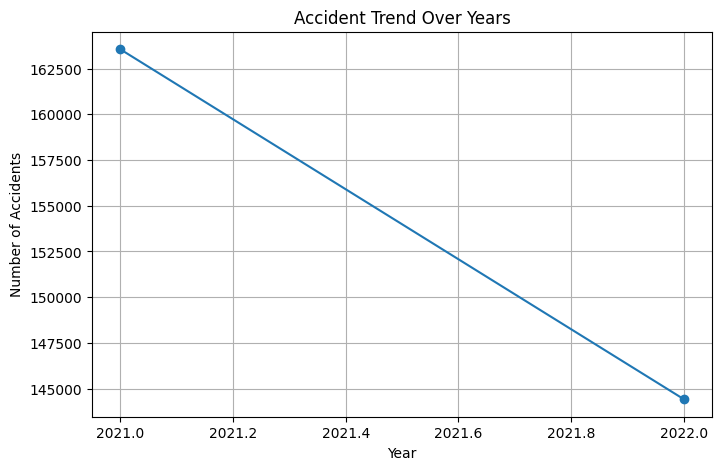

In [522]:
#Visualization of Casualties by Year
plt.figure(figsize=(8,5))
plt.plot(yearly_accidents.index, yearly_accidents.values, marker="o")

plt.title("Accident Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.grid(True)

plt.show()

In [523]:
#Number of Casualties by Month
monthly_accidents=(data.groupby('Month')['Number_of_Casualties'].count().sort_values(ascending=False))
monthly_accidents

Month
Nov    29095
Oct    28368
Jul    26953
Sep    26752
Jun    26748
May    26183
Mar    25543
Aug    25503
Apr    24225
Jan    23384
Dec    23334
Feb    21885
Name: Number_of_Casualties, dtype: int64

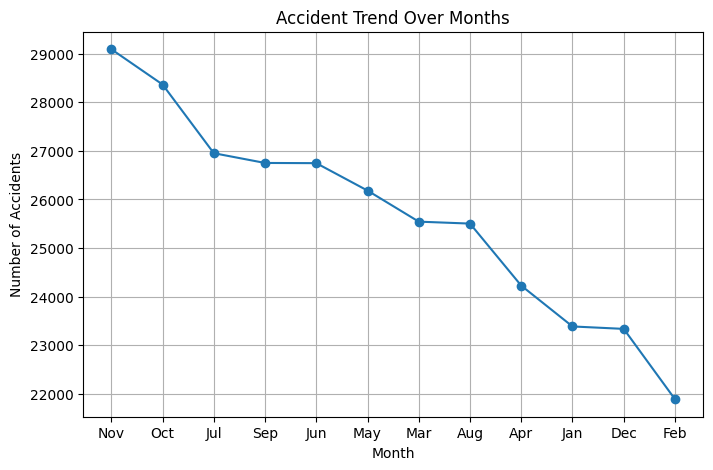

In [524]:
#Visualization of Monthly Trend of Casualties
plt.figure(figsize=(8,5))
plt.plot(monthly_accidents.index, monthly_accidents.values, marker="o")

plt.title("Accident Trend Over Months")
plt.xlabel("Month")
plt.ylabel("Number of Accidents")
plt.grid(True)

plt.show()

In [525]:
#Number of Casualties by Month and Year
data.groupby(['Month', 'Year'])['Number_of_Casualties'].sum().sort_values(ascending=False).head(10)

Month  Year
Nov    2021    20975
Oct    2021    20109
Jul    2021    19682
May    2021    18852
Aug    2021    18797
Jun    2021    18728
Dec    2021    18576
Sep    2021    18456
Nov    2022    18439
Oct    2022    18287
Name: Number_of_Casualties, dtype: int64

In [526]:
#Number of Casualties by Day of Week
day_of_week=data.groupby('Day_of_Week')['Number_of_Casualties'].sum().sort_values(ascending=False).sort_values()
day_of_week

Day_of_Week
Sunday       48858
Monday       58473
Saturday     59090
Thursday     60551
Tuesday      61278
Wednesday    61339
Friday       68294
Name: Number_of_Casualties, dtype: int64

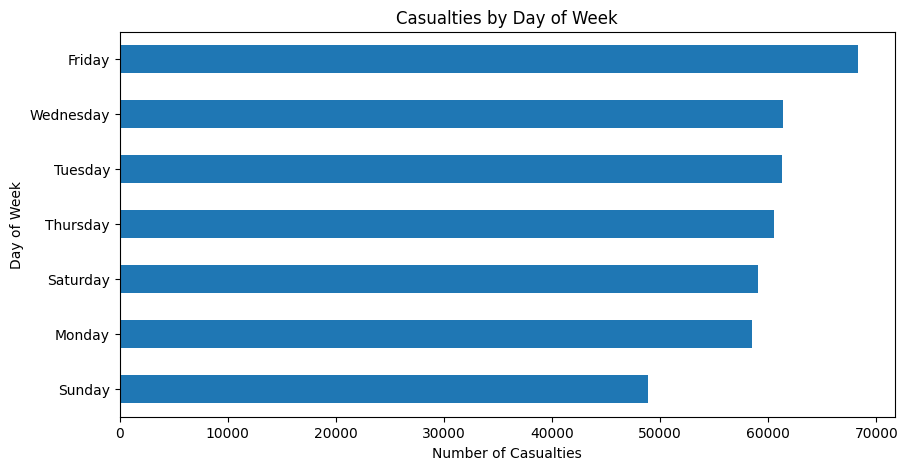

In [527]:
#Visualization of Casualties by Day of Week
day_of_week.plot(kind='barh', figsize=(10,5) )
plt.title('Casualties by Day of Week')
plt.xlabel('Number of Casualties')
plt.ylabel('Day of Week')
plt.show()

In [528]:
#Number of Casualties by Junction Control
junction_control=data.groupby('Junction_Control')['Number_of_Casualties'].sum().sort_values(ascending=False).sort_values()
junction_control

Junction_Control
Authorised person                         581
Stop sign                                2463
Not at junction or within 20 metres     36132
Auto traffic signal                     44197
Data missing or out of range           134606
Give way or uncontrolled               199904
Name: Number_of_Casualties, dtype: int64

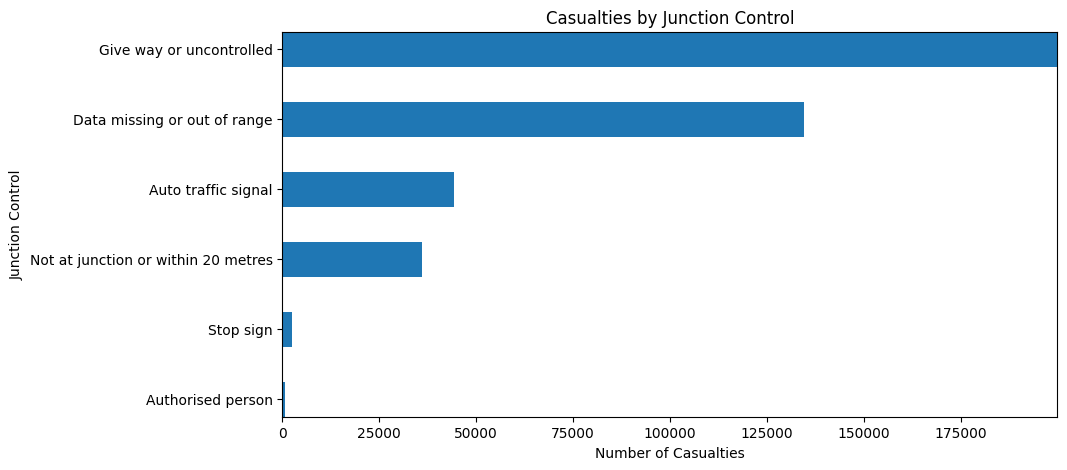

In [529]:
#Visualization of Casualty by Junction Control
junction_control.plot(kind='barh', figsize=(10,5) )
plt.title('Casualties by Junction Control')
plt.xlabel('Number of Casualties')
plt.ylabel('Junction Control')
plt.autoscale(tight=True)
plt.show()

In [530]:
#Number of Casualties by Junction Detail
data.groupby('Junction_Detail')['Number_of_Casualties'].sum().sort_values(ascending=False)

Junction_Detail
Not at junction or within 20 metres    170259
T or staggered junction                127432
Crossroads                              42563
Roundabout                              35085
Private drive or entrance               14618
Other junction                          11239
Slip road                                6358
More than 4 arms (not roundabout)        5874
Mini-roundabout                          4455
Name: Number_of_Casualties, dtype: int64

In [531]:
#Number of Casualties by Accident Severity
data.groupby('Accident_Severity')['Number_of_Casualties'].sum().sort_values(ascending=False)

Accident_Severity
Slight     351436
Serious     59312
Fatal        7135
Name: Number_of_Casualties, dtype: int64

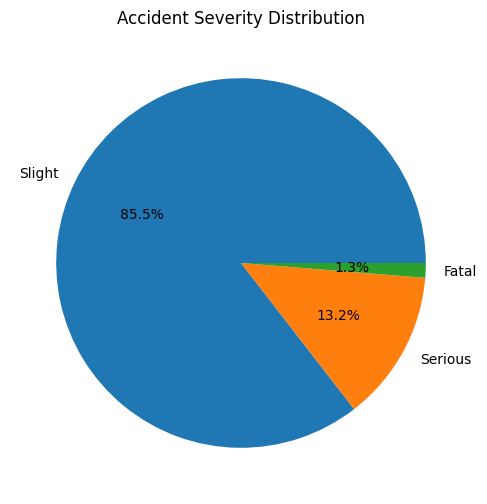

In [532]:
#Visualization of Casualties by Severity
severity_counts = data["Accident_Severity"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(severity_counts, labels=severity_counts.index, autopct='%1.1f%%')

plt.title("Accident Severity Distribution")
plt.show()

In [533]:
#Number of Casualties by Speed limit
data.groupby('Speed_limit')['Number_of_Casualties'].sum().sort_values(ascending=False)

Speed_limit
30    255418
60     71402
40     37199
70     35034
50     15373
20      3450
10         4
15         3
Name: Number_of_Casualties, dtype: int64

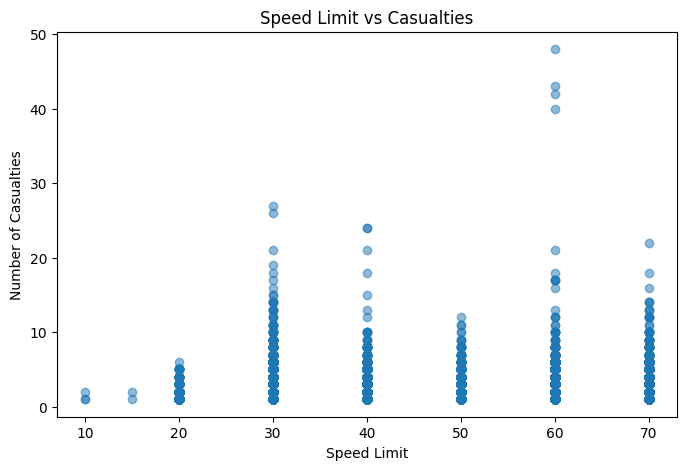

In [534]:
#Scatter Plot for Casualties by Speed Limit
plt.figure(figsize=(8,5))
plt.scatter(data["Speed_limit"], data["Number_of_Casualties"], alpha=0.5)

plt.title("Speed Limit vs Casualties")
plt.xlabel("Speed Limit")
plt.ylabel("Number of Casualties")

plt.show()

In [535]:
#Number of Casualties by Light Conditions
data.groupby('Light_Conditions')['Number_of_Casualties'].sum().sort_values(ascending=False)

Light_Conditions
Daylight                       304963
Darkness - lights lit           82167
Darkness - no lighting          25386
Darkness - lighting unknown      3829
Darkness - lights unlit          1538
Name: Number_of_Casualties, dtype: int64

In [536]:
#Number of Casualties by Road Surface Conditions
road_surface=data.groupby('Road_Surface_Conditions')['Number_of_Casualties'].sum().sort_values(ascending=False).sort_values()
road_surface

Road_Surface_Conditions
Normal                     396
Flood over 3cm. deep       564
Snow                      6475
Frost or ice             16306
Wet or damp             114697
Dry                     279445
Name: Number_of_Casualties, dtype: int64

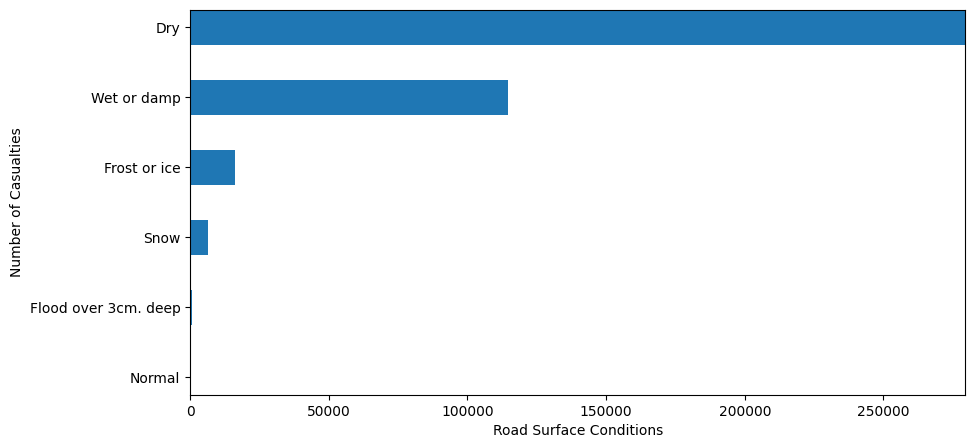

In [537]:
#Visualization of Casualties by Road Surface Conditions
road_surface.plot(kind='barh', figsize=(10,5))
plt.xlabel('Road Surface Conditions')
plt.ylabel('Number of Casualties')
plt.autoscale(tight=True)
plt.show()

In [538]:
#Number of Casualties by Road type
data.groupby('Road_Type')['Number_of_Casualties'].sum().sort_values(ascending=False)

Road_Type
Single carriageway    309698
Dual carriageway       67368
Roundabout             26828
One way street          7389
Slip road               4679
Other                   1921
Name: Number_of_Casualties, dtype: int64

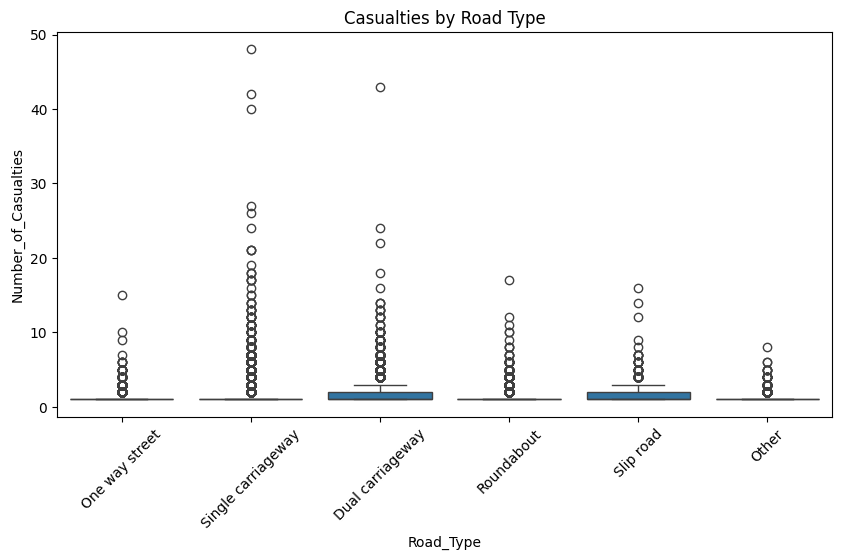

In [539]:
#Boxplot for Road Type
plt.figure(figsize=(10,5))
sns.boxplot(x="Road_Type", y="Number_of_Casualties", data=data)

plt.title("Casualties by Road Type")
plt.xticks(rotation=45)

plt.show()

In [540]:
#Number of Casualties by Area(Urban/Rural)
data.groupby('Urban_or_Rural_Area')['Number_of_Casualties'].sum().sort_values(ascending=False)

Urban_or_Rural_Area
Urban    255864
Rural    162019
Name: Number_of_Casualties, dtype: int64

In [541]:
#Number of Casualties by Weather Conditions
data.groupby('Weather_Conditions')['Number_of_Casualties'].sum().sort_values(ascending=False)

Weather_Conditions
Fine no high winds       330311
Raining no high winds     49082
Other                     19556
Snowing no high winds      6486
Raining + high winds       4936
Fine + high winds          4339
Fog or mist                2410
Snowing + high winds        763
Name: Number_of_Casualties, dtype: int64

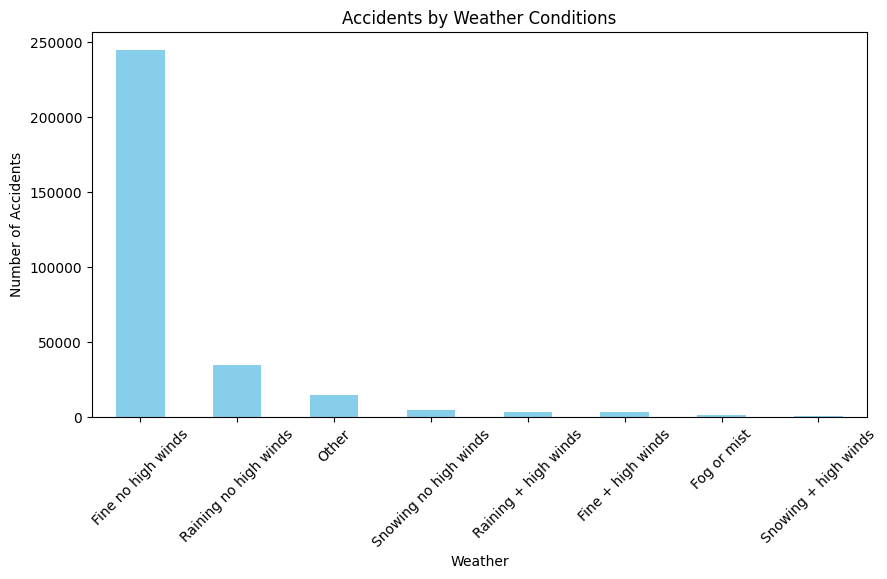

In [542]:
#Visualization of Accidents by Weather Conditions
weather_counts = data["Weather_Conditions"].value_counts()

plt.figure(figsize=(10,5))
weather_counts.plot(kind="bar", color="skyblue")

plt.title("Accidents by Weather Conditions")
plt.xlabel("Weather")
plt.ylabel("Number of Accidents")

plt.xticks(rotation=45)
plt.show()

In [543]:
#Number of Casualties by Vehicle Type
data.groupby('Vehicle_Type')['Number_of_Casualties'].sum().sort_values(ascending=False).head(10)

Vehicle_Type
Car                                      325922
Van / Goods 3.5 tonnes mgw or under       21298
Motorcycle over 500cc                     15151
Bus or coach (17 or more pass seats)      11710
Motorcycle 125cc and under                 9109
Goods 7.5 tonnes mgw and over              8770
Taxi/Private hire car                      7563
Motorcycle 50cc and under                  4945
Motorcycle over 125cc and up to 500cc      4467
Goods over 3.5t. and under 7.5t            3404
Name: Number_of_Casualties, dtype: int64

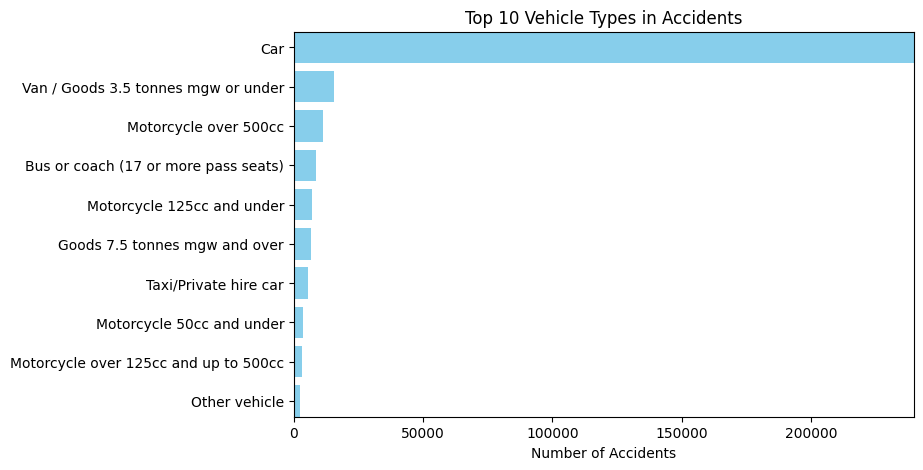

In [544]:
#Visualization of Accidents by Vehicle Type
vehicle_counts = data["Vehicle_Type"].value_counts().head(10)

vehicle_counts = vehicle_counts.sort_values()

plt.figure(figsize=(8,5))
plt.barh(vehicle_counts.index, vehicle_counts.values, color="skyblue")
plt.autoscale(tight=True)

plt.title("Top 10 Vehicle Types in Accidents")
plt.xlabel("Number of Accidents")

plt.show()

In [545]:
#Number of Casualties by Time
data.groupby('Time')['Number_of_Casualties'].sum().sort_values(ascending=False).head(10)

Time
17:00:00    3777
17:30:00    3616
15:30:00    3578
16:00:00    3457
18:00:00    3427
16:30:00    3237
15:00:00    3077
13:00:00    2984
08:30:00    2926
14:00:00    2871
Name: Number_of_Casualties, dtype: int64

In [546]:
#Number of Casualties by Date
data.groupby('Accident Date')['Number_of_Casualties'].sum().sort_values(ascending=False).head(10)

Accident Date
2021-10-06    927
2021-11-13    908
2021-02-11    907
2021-11-06    879
2021-11-03    867
2021-12-04    865
2022-10-01    864
2021-11-12    856
2021-07-17    853
2021-12-11    849
Name: Number_of_Casualties, dtype: int64

In [547]:
#Number of Casualties by Accident date and time
data.groupby(['Accident Date','Time'])['Number_of_Casualties'].sum().sort_values(ascending=False).head(10)

Accident Date  Time    
2021-12-22     22:10:00    48
2022-12-24     15:30:00    44
2022-09-24     08:17:00    44
2022-05-24     15:47:00    40
2022-01-07     12:39:00    27
2022-05-18     15:50:00    27
2021-09-25     13:40:00    27
2021-01-21     09:00:00    25
2021-03-06     21:46:00    24
2022-07-01     09:05:00    24
Name: Number_of_Casualties, dtype: int64

In [548]:
#Fatality Rate
fatal_rate=(data[data['Accident_Severity']=='Fatal'].shape[0]/len(data)*100)
fatal_rate

1.2835540777925338

In [549]:
#Fatality Rate(Alt)
fatal_rate1=(data['Accident_Severity']=='Fatal').value_counts()/len(data['Accident_Severity'])*100
fatal_rate1

Accident_Severity
False    98.716446
True      1.283554
Name: count, dtype: float64

In [550]:
#Accidents by Year
data.groupby('Year')['Accident_Index'].count().sort_values(ascending=False)

Year
2021    163554
2022    144419
Name: Accident_Index, dtype: int64

In [551]:
#Accidents by Month
data.groupby('Month')['Accident_Index'].count().sort_values(ascending=False)

Month
Nov    29095
Oct    28368
Jul    26953
Sep    26752
Jun    26748
May    26183
Mar    25543
Aug    25503
Apr    24225
Jan    23384
Dec    23334
Feb    21885
Name: Accident_Index, dtype: int64

In [552]:
#Accident by District
data.groupby('Local_Authority_(District)')['Accident_Index'].count().sort_values(ascending=False).head()


Local_Authority_(District)
Birmingham     6165
Leeds          4140
Manchester     3132
Bradford       3006
Westminster    2811
Name: Accident_Index, dtype: int64

In [553]:
#Average Casualties by Vehicles
(data['Number_of_Casualties'] / data["Number_of_Vehicles"]).mean()

np.float64(0.8201332661061626)

In [554]:
#Night Accident Rate
night_rate = data[data["Light_Conditions"] == "Darkness"].shape[0] / len(data)
night_rate

0.0

In [555]:
#Night Accident Rate
night_rate1=(data['Light_Conditions']=='Darkness').value_counts()/len(data['Light_Conditions'])*100
night_rate1

Light_Conditions
False    100.0
Name: count, dtype: float64

In [556]:
#Distinct Weather Conditions
data['Weather_Conditions'].unique()

array(['Fine no high winds', 'Other', 'Raining no high winds',
       'Snowing no high winds', 'Fine + high winds',
       'Raining + high winds', 'Snowing + high winds', 'Fog or mist'],
      dtype=object)

In [557]:
#Rate of Accident by Bad Weather
bad_weather=(data['Weather_Conditions']!='Fine').value_counts()/len(data['Weather_Conditions'])*100
bad_weather

Weather_Conditions
True    100.0
Name: count, dtype: float64

In [558]:
#data['Accident Date']=pd.to_datetime(data['Accident Date'], format='%Y-%m-%d')
print(data.columns)

Index(['Accident_Index', 'Accident Date', 'Month', 'Year', 'Day_of_Week',
       'Junction_Control', 'Junction_Detail', 'Accident_Severity', 'Latitude',
       'Light_Conditions', 'Local_Authority_(District)', 'Carriageway_Hazards',
       'Longitude', 'Number_of_Casualties', 'Number_of_Vehicles',
       'Police_Force', 'Road_Surface_Conditions', 'Road_Type', 'Speed_limit',
       'Time', 'Urban_or_Rural_Area', 'Weather_Conditions', 'Vehicle_Type'],
      dtype='object')


In [497]:
#Forecast with Exponential Smoothing
data=data.set_index('Accident Date')
model= ExponentialSmoothing(data['Number_of_Casualties'],
    trend='add',
    seasonal='add',
    seasonal_periods=12)
fit_model=model.fit()
forecast=fit_model.forecast(12)
forecast

/Users/pascalobeng-poku/PyCharmMiscProject/.venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/pascalobeng-poku/PyCharmMiscProject/.venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/pascalobeng-poku/PyCharmMiscProject/.venv/lib/python3.9/site-packages/statsmodels/tsa/holtwinters/model.py:85: RuntimeWarning: overflow encountered in matmul
  return err.T @ err
/Users/pascalobeng-poku/PyCharmMiscProject/.venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction

307973    1.433679
307974    1.428233
307975    1.432304
307976    1.430463
307977    1.434567
307978    1.430519
307979    1.432474
307980    1.442973
307981    1.435200
307982    1.430303
307983    1.433788
307984    1.433536
dtype: float64

In [505]:
print(data.columns)

Index(['Month', 'Year', 'Day_of_Week', 'Junction_Control', 'Junction_Detail',
       'Accident_Severity', 'Latitude', 'Light_Conditions',
       'Local_Authority_(District)', 'Carriageway_Hazards', 'Longitude',
       'Number_of_Casualties', 'Number_of_Vehicles', 'Police_Force',
       'Road_Surface_Conditions', 'Road_Type', 'Speed_limit', 'Time',
       'Urban_or_Rural_Area', 'Weather_Conditions', 'Vehicle_Type'],
      dtype='object')


In [559]:
#Forecast with Prophet
data['ds']= pd.to_datetime(data['Accident Date'])
data=data.rename(columns={'Number_of_Casualties':'y'})

train_data=data[['ds','y']]
model= Prophet(yearly_seasonality=True)
model.fit(train_data)

future=model.make_future_dataframe(periods=12, freq='MS')

forecast=model.predict(future)
forecast.head(10)

16:31:28 - cmdstanpy - INFO - Chain [1] start processing
16:31:42 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2021-01-01,1.372755,0.324026,2.315957,1.372755,1.372755,-0.008152,-0.008152,-0.008152,-0.035549,-0.035549,-0.035549,0.027397,0.027397,0.027397,0.0,0.0,0.0,1.364604
1,2021-01-02,1.372655,0.366073,2.384559,1.372655,1.372655,0.014329,0.014329,0.014329,-0.009970,-0.009970,-0.009970,0.024298,0.024298,0.024298,0.0,0.0,0.0,1.386984
2,2021-01-03,1.372555,0.385764,2.489316,1.372555,1.372555,0.080749,0.080749,0.080749,0.059941,0.059941,0.059941,0.020808,0.020808,0.020808,0.0,0.0,0.0,1.453303
3,2021-01-04,1.372454,0.507348,2.593577,1.372454,1.372454,0.111705,0.111705,0.111705,0.094724,0.094724,0.094724,0.016981,0.016981,0.016981,0.0,0.0,0.0,1.484159
4,2021-01-05,1.372354,0.233573,2.295042,1.372354,1.372354,-0.016772,-0.016772,-0.016772,-0.029649,-0.029649,-0.029649,0.012877,0.012877,0.012877,0.0,0.0,0.0,1.355581
5,2021-01-06,1.372253,0.336645,2.349347,1.372253,1.372253,-0.031803,-0.031803,-0.031803,-0.040362,-0.040362,-0.040362,0.008559,0.008559,0.008559,0.0,0.0,0.0,1.340450
6,2021-01-07,1.372153,0.376041,2.443867,1.372153,1.372153,-0.035040,-0.035040,-0.035040,-0.039135,-0.039135,-0.039135,0.004095,0.004095,0.004095,0.0,0.0,0.0,1.337113
7,2021-01-08,1.372052,0.279308,2.407981,1.372052,1.372052,-0.035994,-0.035994,-0.035994,-0.035549,-0.035549,-0.035549,-0.000445,-0.000445,-0.000445,0.0,0.0,0.0,1.336058
8,2021-01-09,1.371952,0.322844,2.447687,1.371952,1.371952,-0.014961,-0.014961,-0.014961,-0.009970,-0.009970,-0.009970,-0.004991,-0.004991,-0.004991,0.0,0.0,0.0,1.356991
9,2021-01-10,1.371851,0.353185,2.436477,1.371851,1.371851,0.050466,0.050466,0.050466,0.059941,0.059941,0.059941,-0.009475,-0.009475,-0.009475,0.0,0.0,0.0,1.422317


In [560]:
forecast.tail(12)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
730,2023-01-01,1.377370,0.438266,2.424803,1.375971,1.378992,0.088725,0.088725,0.088725,0.059941,0.059941,0.059941,0.028785,0.028785,0.028785,0.0,0.0,0.0,1.466095
731,2023-02-01,1.381983,0.255585,2.323559,1.377642,1.387168,-0.060448,-0.060448,-0.060448,-0.040362,-0.040362,-0.040362,-0.020086,-0.020086,-0.020086,0.0,0.0,0.0,1.321535
732,2023-03-01,1.386150,0.288014,2.282887,1.377218,1.396208,-0.060314,-0.060314,-0.060314,-0.040362,-0.040362,-0.040362,-0.019951,-0.019951,-0.019951,0.0,0.0,0.0,1.325836
733,2023-04-01,1.390763,0.303442,2.379734,1.376351,1.406114,0.011015,0.011015,0.011015,-0.009970,-0.009970,-0.009970,0.020985,0.020985,0.020985,0.0,0.0,0.0,1.401778
734,2023-05-01,1.395227,0.441198,2.573227,1.375453,1.416938,0.088555,0.088555,0.088555,0.094724,0.094724,0.094724,-0.006168,-0.006168,-0.006168,0.0,0.0,0.0,1.483783
735,2023-06-01,1.399841,0.303138,2.338108,1.373667,1.428164,-0.030896,-0.030896,-0.030896,-0.039135,-0.039135,-0.039135,0.008238,0.008238,0.008238,0.0,0.0,0.0,1.368944
736,2023-07-01,1.404305,0.294162,2.428771,1.371331,1.439857,-0.023127,-0.023127,-0.023127,-0.009970,-0.009970,-0.009970,-0.013157,-0.013157,-0.013157,0.0,0.0,0.0,1.381178
737,2023-08-01,1.408918,0.417065,2.456251,1.368275,1.452299,-0.005094,-0.005094,-0.005094,-0.029649,-0.029649,-0.029649,0.024555,0.024555,0.024555,0.0,0.0,0.0,1.403824
738,2023-09-01,1.413532,0.283339,2.445105,1.364965,1.465452,-0.009420,-0.009420,-0.009420,-0.035549,-0.035549,-0.035549,0.026129,0.026129,0.026129,0.0,0.0,0.0,1.404111
739,2023-10-01,1.417996,0.360419,2.523995,1.360604,1.479934,0.040197,0.040197,0.040197,0.059941,0.059941,0.059941,-0.019744,-0.019744,-0.019744,0.0,0.0,0.0,1.458193


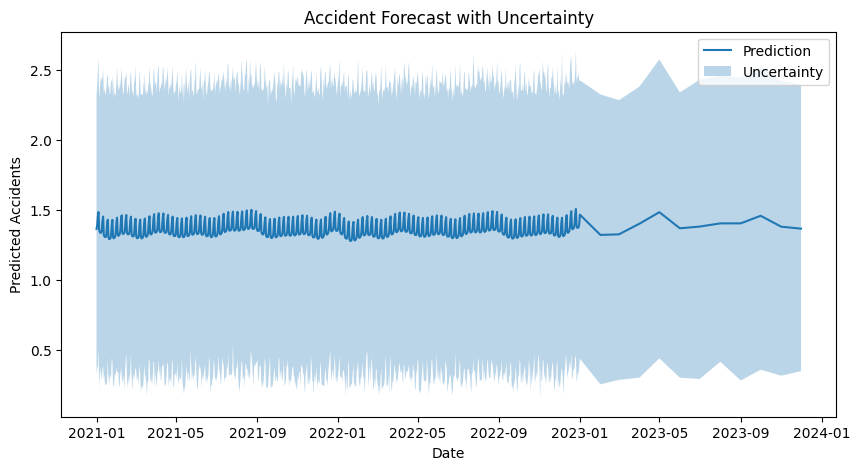

In [561]:
#Visualization of Forecast using Prophet
plt.figure(figsize=(10,5))
plt.plot(forecast["ds"], forecast["yhat"], label="Prediction")
plt.fill_between(
    forecast["ds"],
    forecast["yhat_lower"],
    forecast["yhat_upper"],
    alpha=0.3,
    label="Uncertainty"
)

plt.title("Accident Forecast with Uncertainty")
plt.xlabel("Date")
plt.ylabel("Predicted Accidents")
plt.legend()
plt.show()

In [563]:
data.to_csv("Road Accident_Cleaned", index=False)